<a href="https://colab.research.google.com/github/hwangho-kim/Transformer_Fewshot_PdM/blob/main/Production_FDC_Pipeline_read_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[System] Using device: cpu

Phase 1: Loading data from CSV...
Running DTW alignment (Parallel Processing)...
Data ready! Pre-train: 800, Few-shot: 20, Test: 180

Phase 2: Foundation Model Training...
-> Found existing model weights: factory_data/foundation_model.pth
Phase 3: Fine-Tuning with Few-Shot Data...
Fine-tuning completed.

Phase 4: Evaluating Test Data & Dynamic UCL...


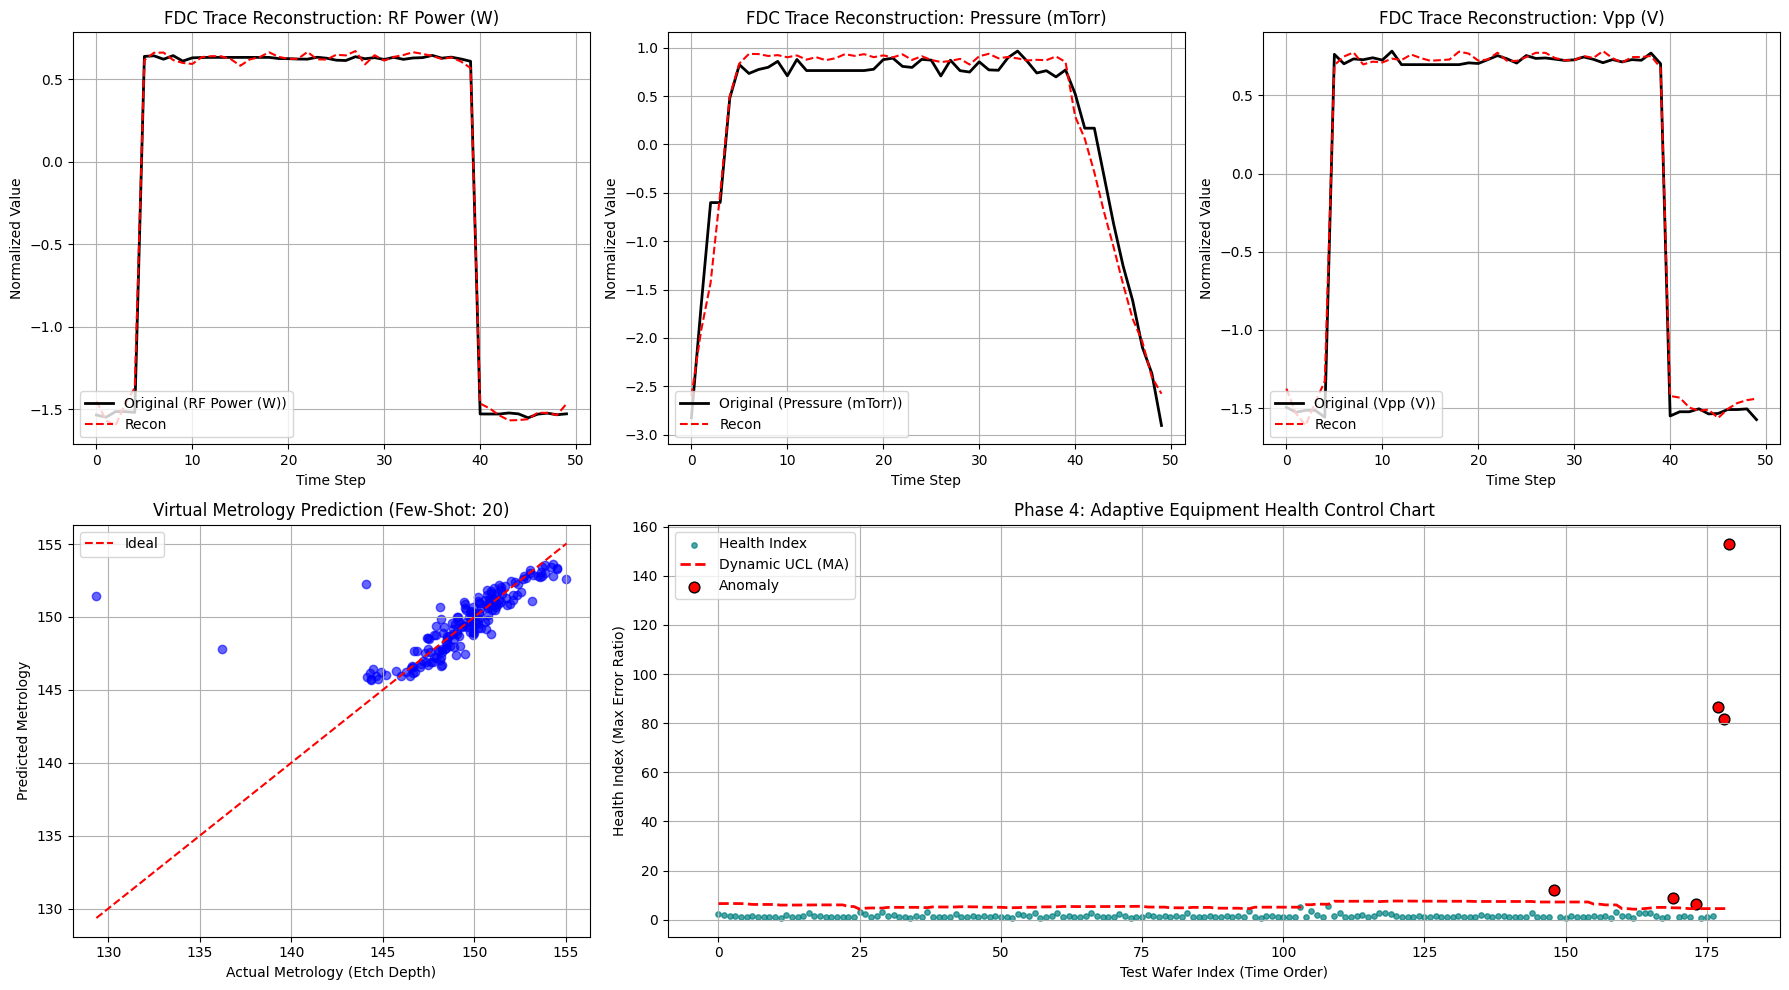

Test RMSE: 2.13
-> VM 및 진단 결과 CSV 저장 완료: fdc_outputs/05_phase4_vm_test_results.csv


Phase 5: XAI Root Cause Analysis


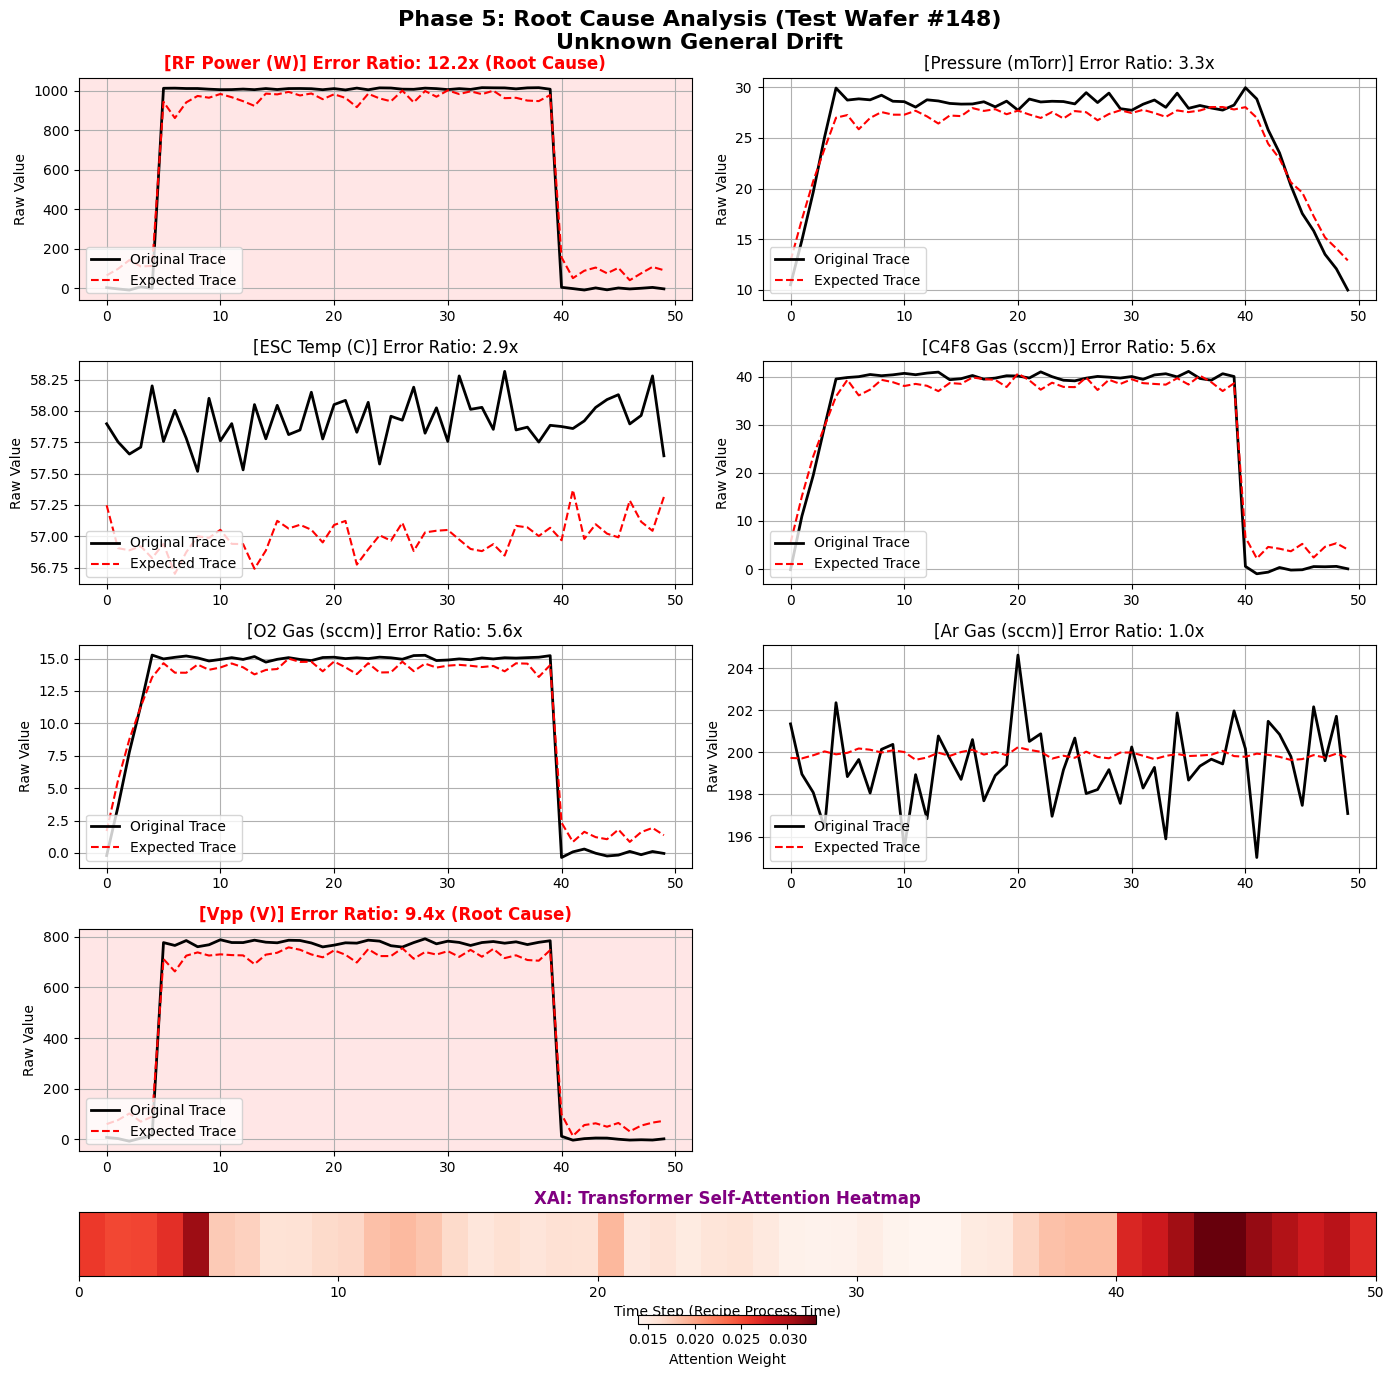


📑 [자동 진단 리포트] Test Wafer #148 불량 분석 요약
   ▶ 인지된 시나리오 타입: 알 수 없는 일반적 이상(General Drift)
🚨 문제 원인 센서: RF Power (W), Vpp (V)
      * RF Power (W): 평소 정상 대비 오차가 12.2배 폭증함
      * Vpp (V): 평소 정상 대비 오차가 9.4배 폭증함

⏱️ 주요 이상 의심 시점 (AI Attention 모델의 시선):
   -> 전체 50 스텝 중 '44번째 스텝' 부근 (퍼지 및 오버에치 구간에서) 비정상적인 패턴이 감지되었습니다.



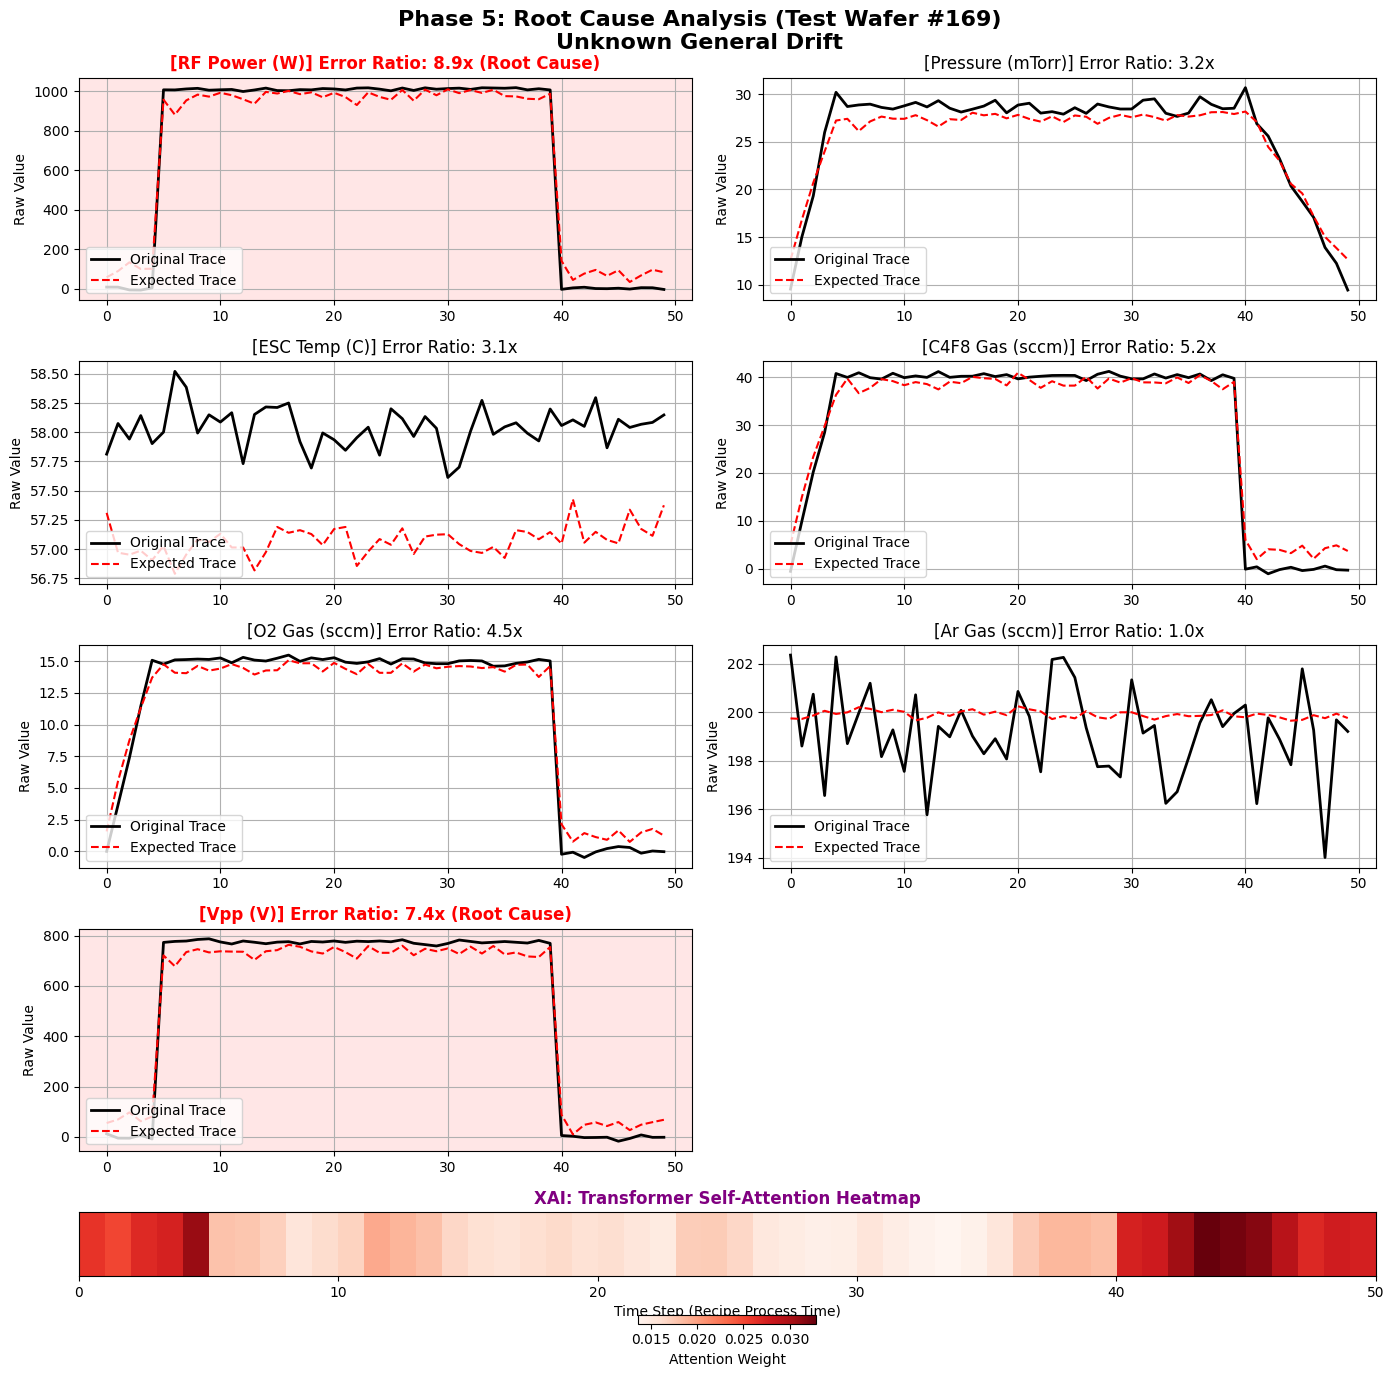


📑 [자동 진단 리포트] Test Wafer #169 불량 분석 요약
   ▶ 인지된 시나리오 타입: 알 수 없는 일반적 이상(General Drift)
🚨 문제 원인 센서: RF Power (W), Vpp (V)
      * RF Power (W): 평소 정상 대비 오차가 8.9배 폭증함
      * Vpp (V): 평소 정상 대비 오차가 7.4배 폭증함

⏱️ 주요 이상 의심 시점 (AI Attention 모델의 시선):
   -> 전체 50 스텝 중 '43번째 스텝' 부근 (퍼지 및 오버에치 구간에서) 비정상적인 패턴이 감지되었습니다.



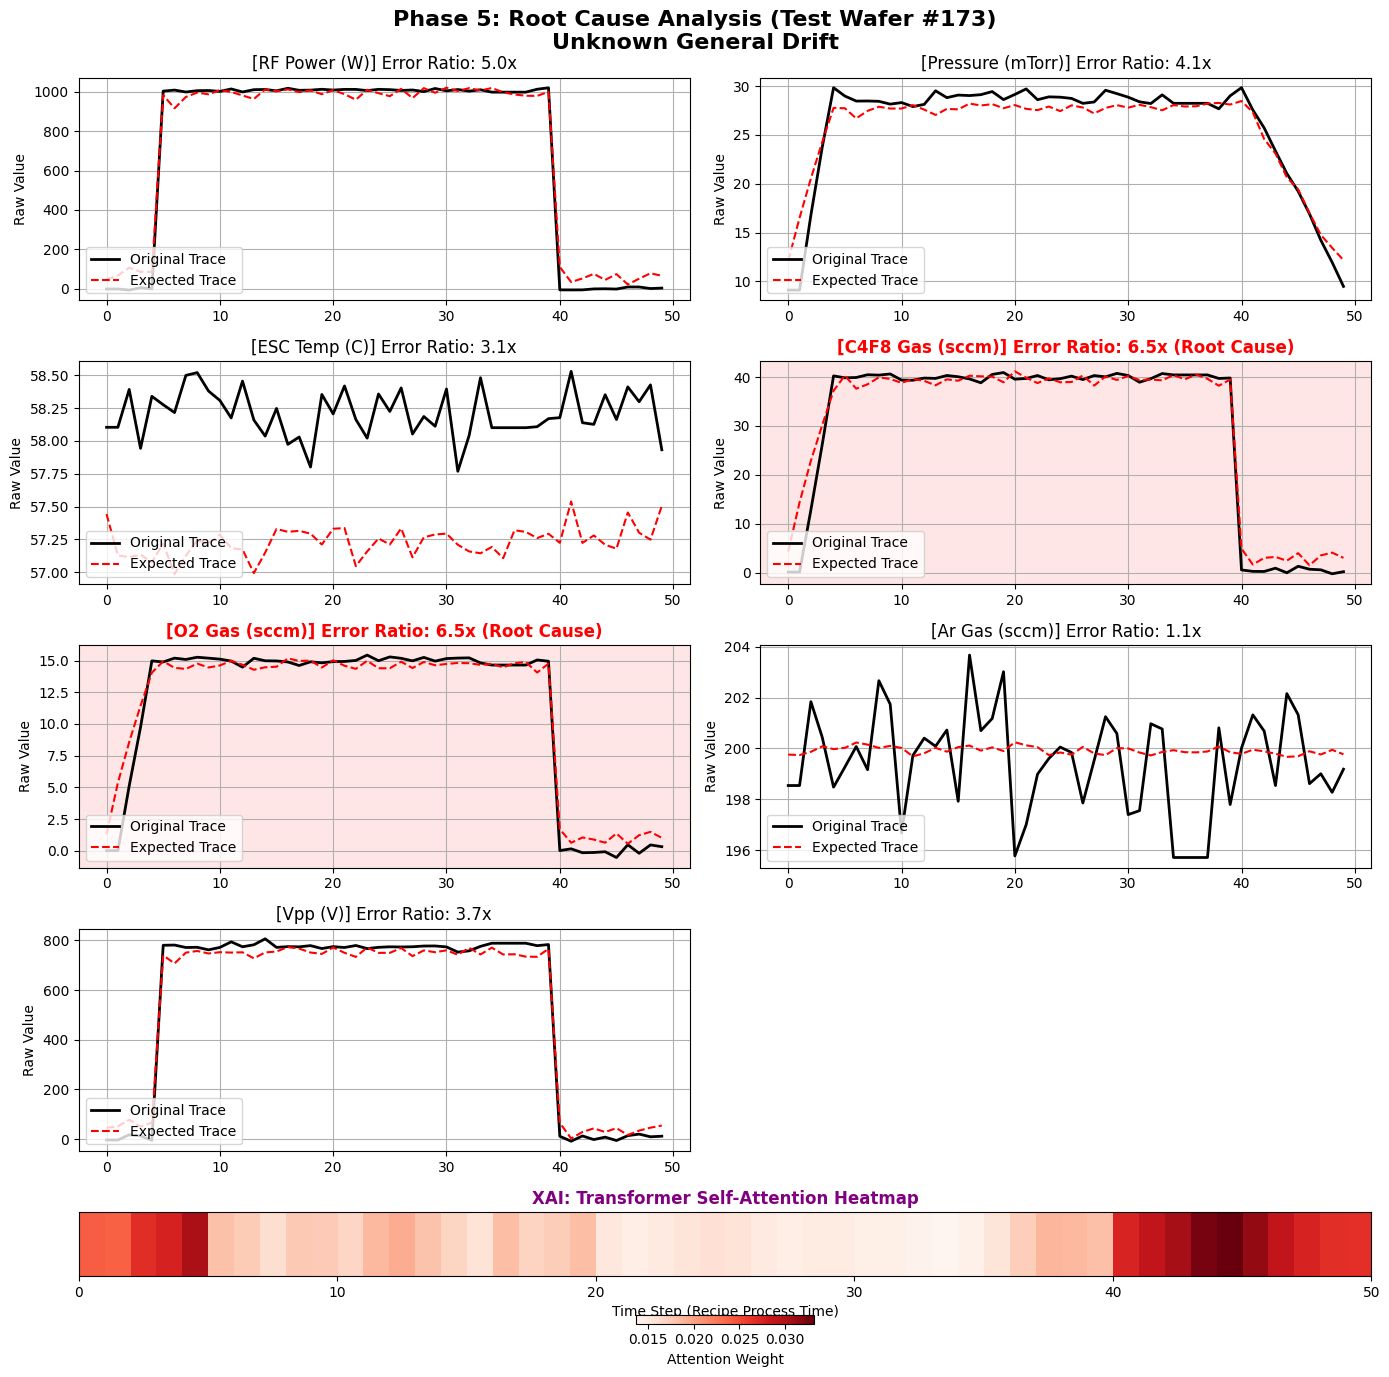


📑 [자동 진단 리포트] Test Wafer #173 불량 분석 요약
   ▶ 인지된 시나리오 타입: 알 수 없는 일반적 이상(General Drift)
🚨 문제 원인 센서: C4F8 Gas (sccm), O2 Gas (sccm)
      * C4F8 Gas (sccm): 평소 정상 대비 오차가 6.5배 폭증함
      * O2 Gas (sccm): 평소 정상 대비 오차가 6.5배 폭증함

⏱️ 주요 이상 의심 시점 (AI Attention 모델의 시선):
   -> 전체 50 스텝 중 '44번째 스텝' 부근 (퍼지 및 오버에치 구간에서) 비정상적인 패턴이 감지되었습니다.



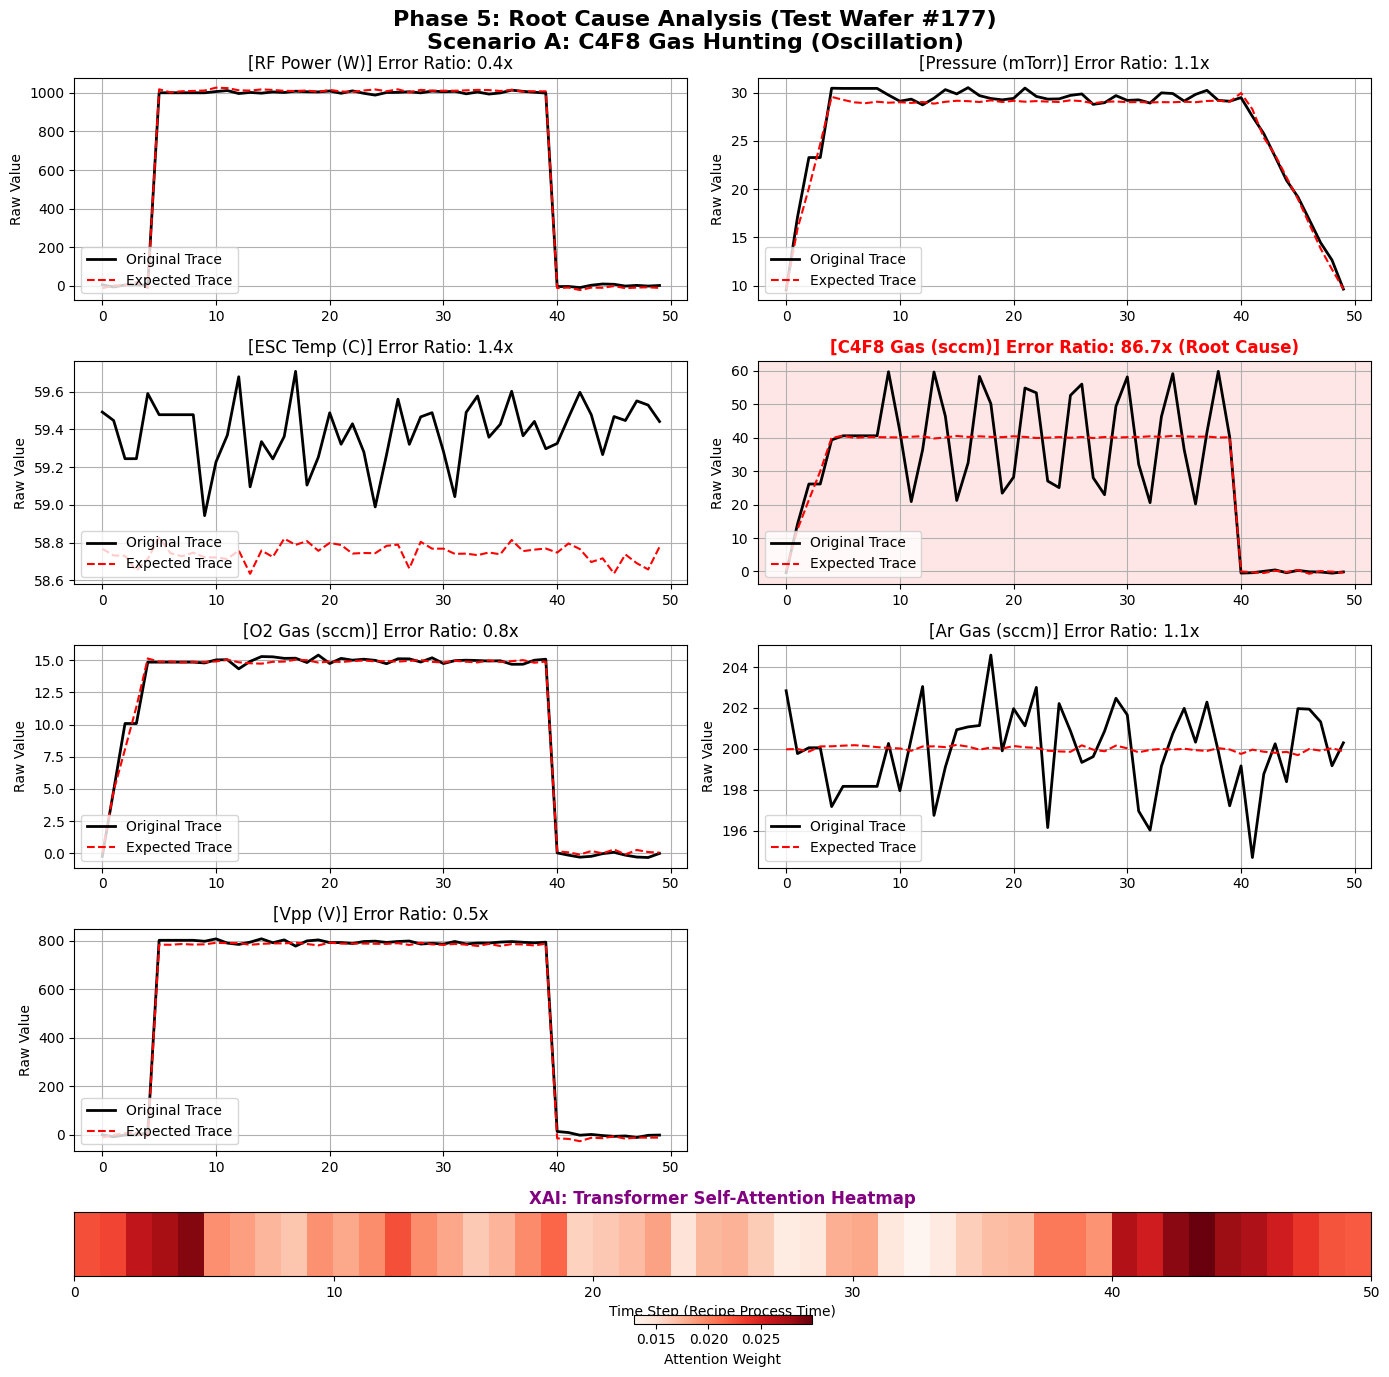


📑 [자동 진단 리포트] Test Wafer #177 불량 분석 요약
   ▶ 인지된 시나리오 타입: [시나리오 A] C4F8 Gas 유량 헌팅 (Hunting/Oscillation)
🚨 문제 원인 센서: C4F8 Gas (sccm)
      * C4F8 Gas (sccm): 평소 정상 대비 오차가 86.7배 폭증함

⏱️ 주요 이상 의심 시점 (AI Attention 모델의 시선):
   -> 전체 50 스텝 중 '43번째 스텝' 부근 (퍼지 및 오버에치 구간에서) 비정상적인 패턴이 감지되었습니다.



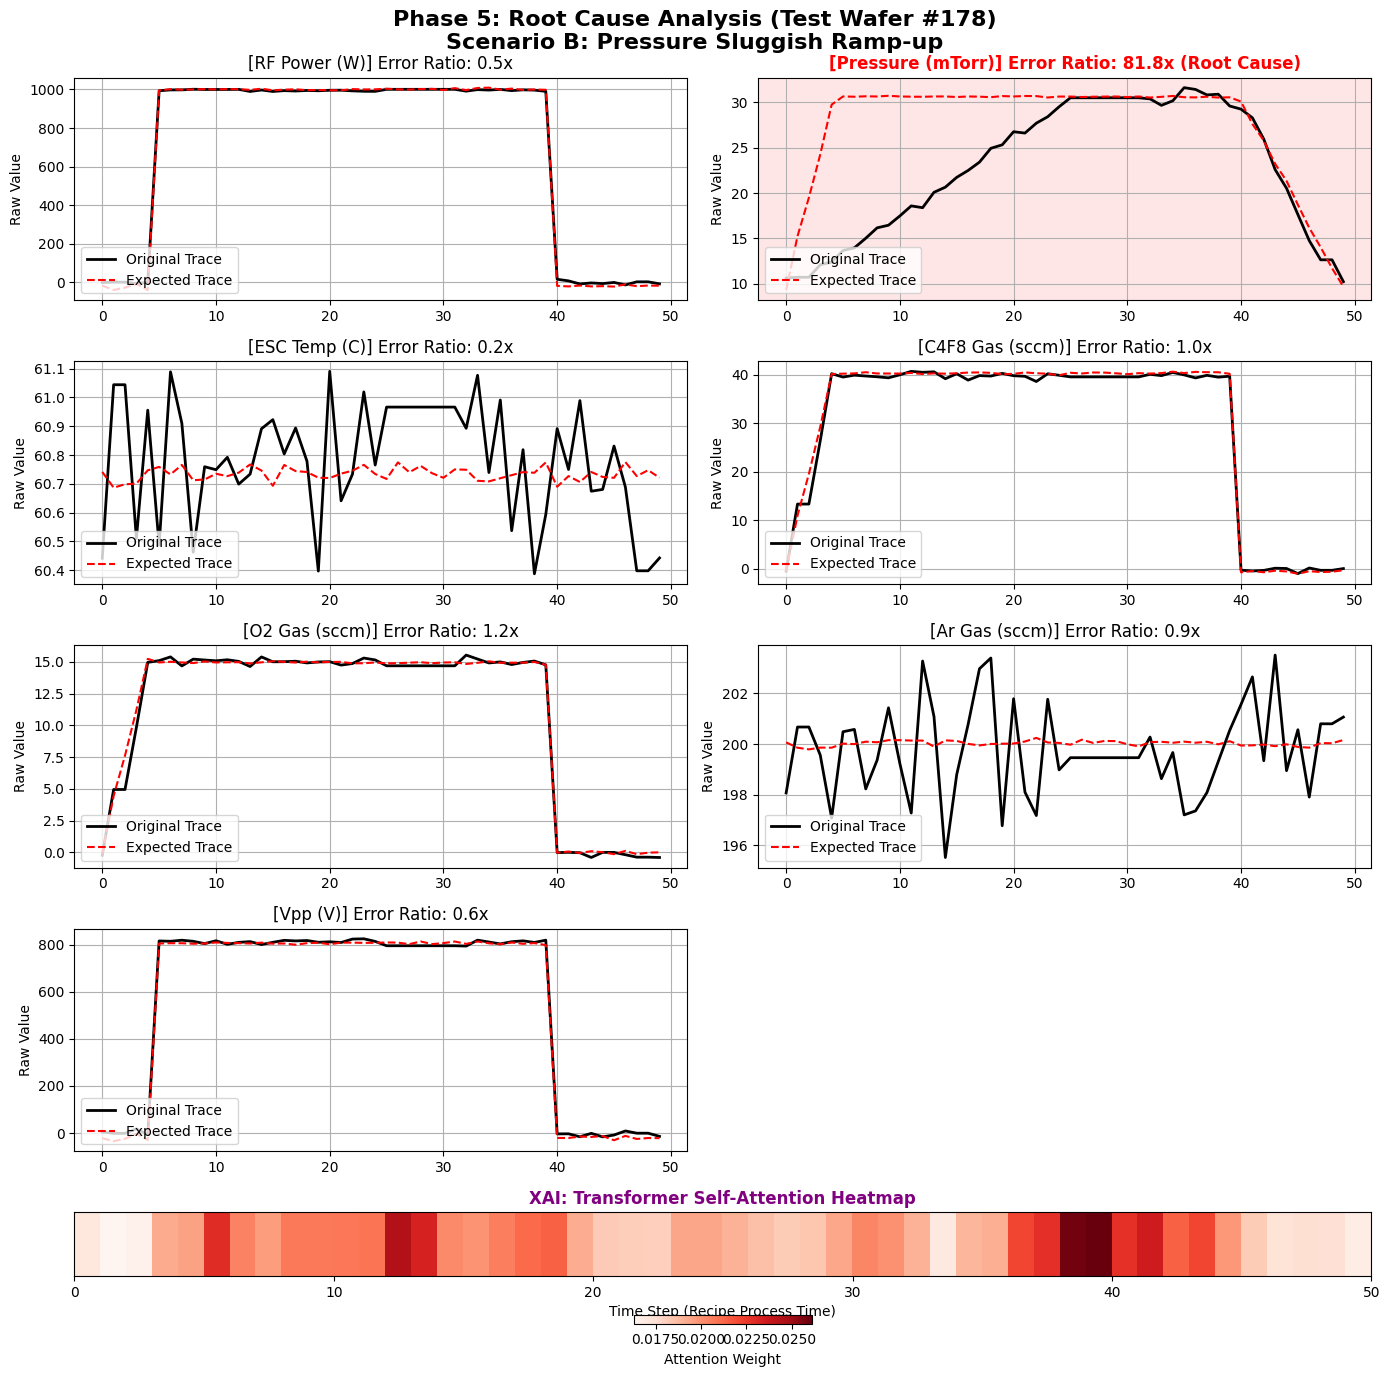


📑 [자동 진단 리포트] Test Wafer #178 불량 분석 요약
   ▶ 인지된 시나리오 타입: [시나리오 B] Pressure 초기 도달 지연 (Sluggish Ramp-up)
🚨 문제 원인 센서: Pressure (mTorr)
      * Pressure (mTorr): 평소 정상 대비 오차가 81.8배 폭증함

⏱️ 주요 이상 의심 시점 (AI Attention 모델의 시선):
   -> 전체 50 스텝 중 '39번째 스텝' 부근 (메인 식각(플라즈마 On) 구간에서) 비정상적인 패턴이 감지되었습니다.



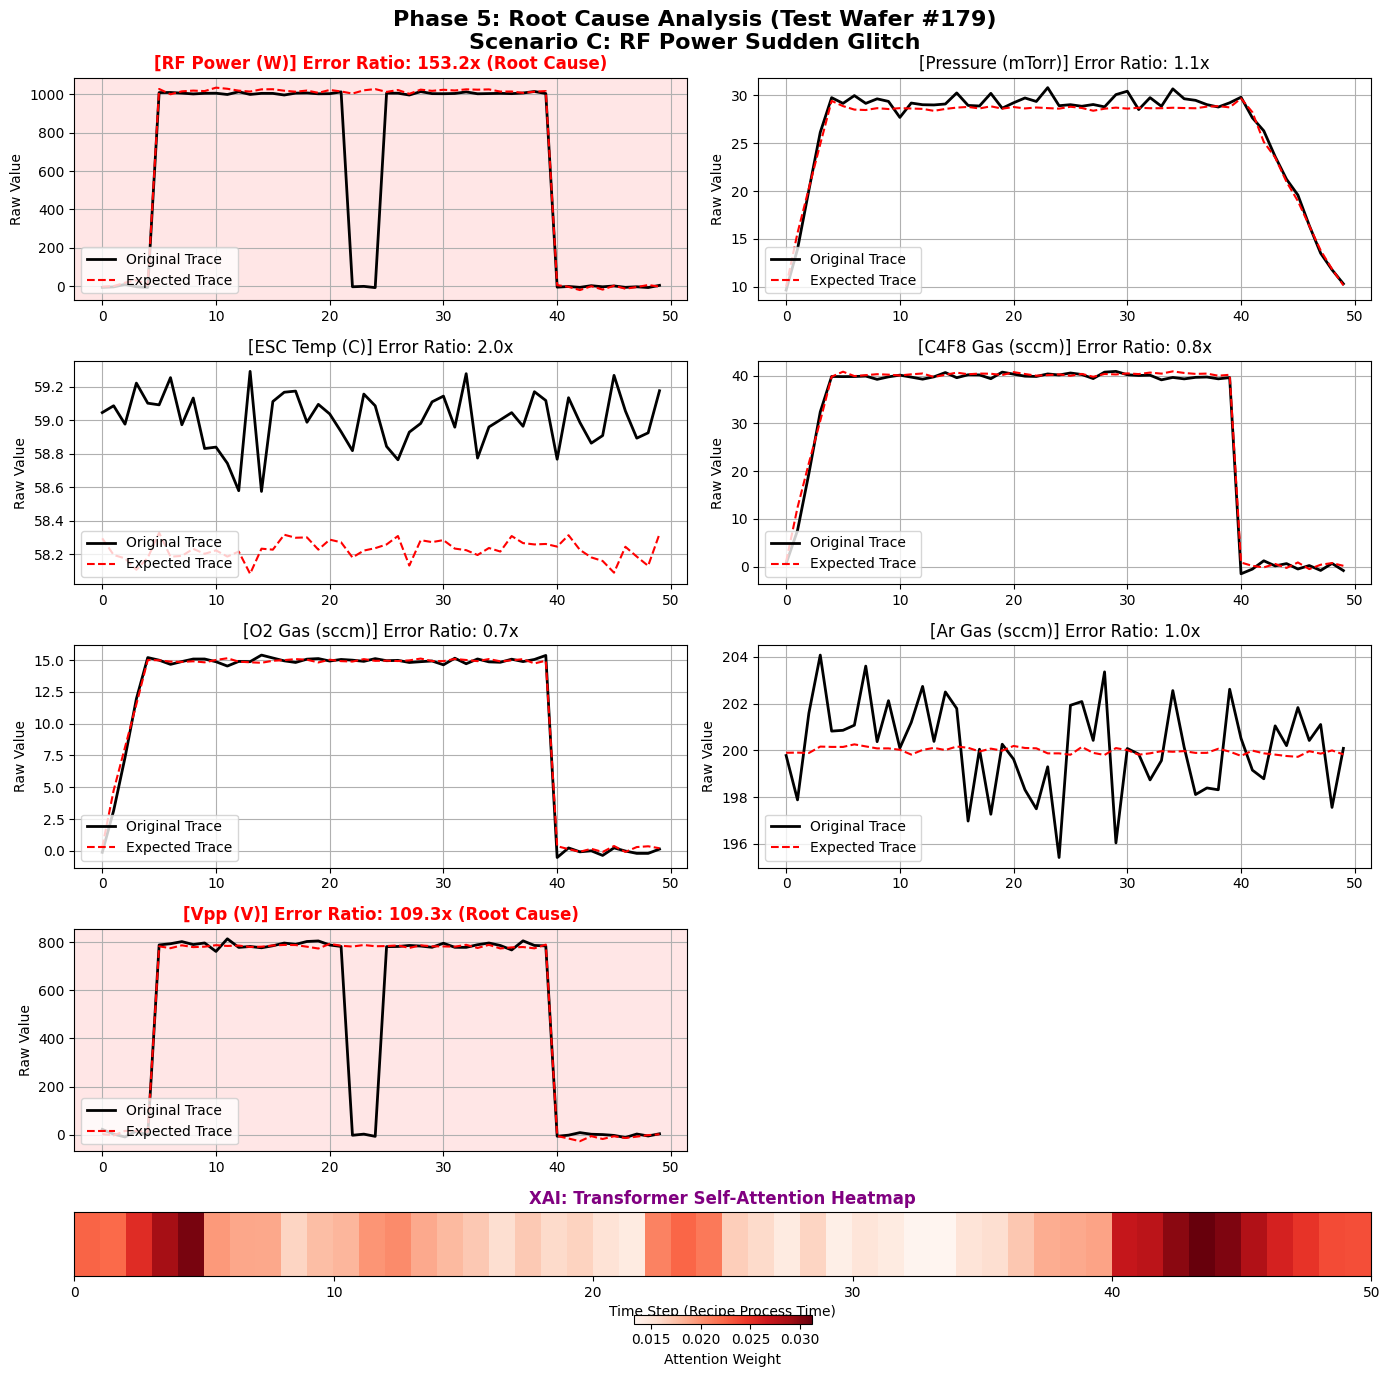


📑 [자동 진단 리포트] Test Wafer #179 불량 분석 요약
   ▶ 인지된 시나리오 타입: [시나리오 C] RF Power 순간 글리치 (Sudden Drop/Spike)
🚨 문제 원인 센서: RF Power (W), Vpp (V)
      * RF Power (W): 평소 정상 대비 오차가 153.2배 폭증함
      * Vpp (V): 평소 정상 대비 오차가 109.3배 폭증함

⏱️ 주요 이상 의심 시점 (AI Attention 모델의 시선):
   -> 전체 50 스텝 중 '43번째 스텝' 부근 (퍼지 및 오버에치 구간에서) 비정상적인 패턴이 감지되었습니다.



In [4]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import os
import math
from concurrent.futures import ThreadPoolExecutor

# 시스템 설정
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"[System] Using device: {device}")

# CSV 파일을 저장할 폴더 생성
output_dir = "fdc_outputs"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# ==========================================
# Phase 1: Data Ingestion & Preprocessing
# ==========================================
print("\nPhase 1: Loading data from CSV...")

data_dir = "factory_data"
trace_csv_path = os.path.join(data_dir, 'raw_fdc_trace.csv')
metro_csv_path = os.path.join(data_dir, 'raw_metrology.csv')

if not os.path.exists(trace_csv_path) or not os.path.exists(metro_csv_path):
    raise FileNotFoundError("CSV files not found. Please run generate_sample_csv.py first.")

# 1-1. CSV 파일 로드
df_trace = pd.read_csv(trace_csv_path)
df_metrology = pd.read_csv(metro_csv_path)

sensor_names = ['RF Power (W)', 'Pressure (mTorr)', 'ESC Temp (C)', 'C4F8 Gas (sccm)', 'O2 Gas (sccm)', 'Ar Gas (sccm)', 'Vpp (V)']
NUM_SENSORS = len(sensor_names)
SEQ_LENGTH = 50
FEW_SHOT_SIZE = 20

# 1-2. DataFrame을 웨이퍼 단위의 배열 리스트로 변환 (Variable Length)
wafer_ids = df_trace['Wafer_ID'].unique()
NUM_WAFERS = len(wafer_ids)
raw_X_data = []

grouped = df_trace.groupby('Wafer_ID')
for w_id in wafer_ids:
    wafer_data = grouped.get_group(w_id)[sensor_names].values
    raw_X_data.append(wafer_data)

y_data = df_metrology['Etch_Depth_nm'].values

scenario_mapping_en = {
    NUM_WAFERS - 3: "Scenario A: C4F8 Gas Hunting (Oscillation)",
    NUM_WAFERS - 2: "Scenario B: Pressure Sluggish Ramp-up",
    NUM_WAFERS - 1: "Scenario C: RF Power Sudden Glitch"
}
scenario_mapping_ko = {
    NUM_WAFERS - 3: "[시나리오 A] C4F8 Gas 유량 헌팅 (Hunting/Oscillation)",
    NUM_WAFERS - 2: "[시나리오 B] Pressure 초기 도달 지연 (Sluggish Ramp-up)",
    NUM_WAFERS - 1: "[시나리오 C] RF Power 순간 글리치 (Sudden Drop/Spike)"
}

# 1-3. DTW 병렬 동기화 (가변 길이 -> 고정 길이 변환)
print("Running DTW alignment (Parallel Processing)...")
ref_trace = np.zeros((SEQ_LENGTH, NUM_SENSORS))
r_step1 = int(SEQ_LENGTH * 0.1)
r_step2 = int(SEQ_LENGTH * 0.8)
ref_trace[r_step1:r_step2, 0] = 1000
ref_trace[:r_step1, 1] = np.linspace(10, 30, r_step1)
ref_trace[r_step1:r_step2, 1] = 30
ref_trace[r_step2:, 1] = np.linspace(30, 10, SEQ_LENGTH - r_step2)
ref_trace[:, 2] = 60
ref_trace[:r_step1, 3] = np.linspace(0, 40, r_step1)
ref_trace[r_step1:r_step2, 3] = 40
ref_trace[:r_step1, 4] = np.linspace(0, 15, r_step1)
ref_trace[r_step1:r_step2, 4] = 15
ref_trace[:, 5] = 200
ref_trace[r_step1:r_step2, 6] = 800

def align_single_trace(raw_trace):
    distance, path = fastdtw(ref_trace, raw_trace, dist=euclidean)
    aligned_trace = np.zeros_like(ref_trace)
    counts = np.zeros(SEQ_LENGTH)
    for ref_idx, raw_idx in path:
        aligned_trace[ref_idx] += raw_trace[raw_idx]
        counts[ref_idx] += 1
    aligned_trace = aligned_trace / counts[:, np.newaxis]
    return aligned_trace

with ThreadPoolExecutor() as executor:
    X_data = list(executor.map(align_single_trace, raw_X_data))
X_data = np.array(X_data)

# 1-4. 데이터 스플릿 및 스케일링
X_pretrain = X_data[:800]
X_fewshot = X_data[800:800+FEW_SHOT_SIZE]
y_fewshot = y_data[800:800+FEW_SHOT_SIZE]
X_test = X_data[800+FEW_SHOT_SIZE:]
y_test = y_data[800+FEW_SHOT_SIZE:]

scaler = StandardScaler()
X_pretrain_scaled = scaler.fit_transform(X_pretrain.reshape(-1, NUM_SENSORS)).reshape(X_pretrain.shape)
X_fewshot_scaled = scaler.transform(X_fewshot.reshape(-1, NUM_SENSORS)).reshape(X_fewshot.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, NUM_SENSORS)).reshape(X_test.shape)

y_scaler = StandardScaler()
y_fewshot_scaled = y_scaler.fit_transform(y_fewshot.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).flatten()

train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_pretrain_scaled)), batch_size=64, shuffle=True)
fewshot_loader = DataLoader(TensorDataset(torch.FloatTensor(X_fewshot_scaled), torch.FloatTensor(y_fewshot_scaled)), batch_size=4, shuffle=True)
test_loader = DataLoader(TensorDataset(torch.FloatTensor(X_test_scaled), torch.FloatTensor(y_test_scaled)), batch_size=32, shuffle=False)

print(f"Data ready! Pre-train: {len(X_pretrain)}, Few-shot: {len(X_fewshot)}, Test: {len(X_test)}\n")

# ==========================================
# Models Architecture (Transformer)
# ==========================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(1), :].unsqueeze(0)

class CustomTransformerLayer(nn.Module):
    def __init__(self, d_model, nhead):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.ReLU(),
            nn.Linear(d_model * 4, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_output, attn_weights = self.self_attn(x, x, x)
        x = self.norm1(x + attn_output)
        x = self.norm2(x + self.ffn(x))
        return x, attn_weights

class FDCEncoder(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, latent_dim=16):
        super(FDCEncoder, self).__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        self.layers = nn.ModuleList([CustomTransformerLayer(d_model, nhead) for _ in range(num_layers)])
        self.fc_latent = nn.Linear(d_model, latent_dim)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        for layer in self.layers:
            x, attn_weights = layer(x)
        x_mean = x.mean(dim=1)
        latent = self.fc_latent(x_mean)
        return latent, attn_weights

class FDCDecoder(nn.Module):
    def __init__(self, latent_dim, d_model=64, nhead=4, num_layers=2, output_dim=7, seq_len=50):
        super(FDCDecoder, self).__init__()
        self.seq_len = seq_len
        self.latent_proj = nn.Linear(latent_dim, d_model * self.seq_len)
        self.pos_encoder = PositionalEncoding(d_model)
        decoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_decoder = nn.TransformerEncoder(decoder_layers, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, output_dim)

    def forward(self, latent):
        batch_size = latent.size(0)
        x = self.latent_proj(latent).view(batch_size, self.seq_len, -1)
        x = self.pos_encoder(x)
        x = self.transformer_decoder(x)
        reconstruction = self.fc_out(x)
        return reconstruction

class FDCFoundationModel(nn.Module):
    def __init__(self, input_dim=NUM_SENSORS, d_model=64, latent_dim=16, seq_len=50):
        super(FDCFoundationModel, self).__init__()
        self.encoder = FDCEncoder(input_dim, d_model=d_model, latent_dim=latent_dim)
        self.decoder = FDCDecoder(latent_dim, d_model=d_model, output_dim=input_dim, seq_len=seq_len)

    def forward(self, x):
        latent, attn_weights = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction, attn_weights

class FDCVirtualMetrologyModel(nn.Module):
    def __init__(self, encoder):
        super(FDCVirtualMetrologyModel, self).__init__()
        self.encoder = encoder
        self.regressor = nn.Sequential(nn.Linear(16, 8), nn.ReLU(), nn.Linear(8, 1))

    def forward(self, x):
        latent, _ = self.encoder(x)
        prediction = self.regressor(latent)
        return prediction.squeeze(-1)

# ==========================================
# Phase 2 & 3: Model Training
# ==========================================
print("Phase 2: Foundation Model Training...")
foundation_model = FDCFoundationModel(input_dim=NUM_SENSORS).to(device)
criterion_reconstruction = nn.MSELoss()
optimizer_pretrain = optim.Adam(foundation_model.parameters(), lr=0.001)

MODEL_SAVE_PATH = os.path.join(data_dir, 'foundation_model.pth')

if os.path.exists(MODEL_SAVE_PATH):
    print(f"-> Found existing model weights: {MODEL_SAVE_PATH}")
    foundation_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
else:
    print("-> Training new Foundation Model...")
    EPOCHS_PRETRAIN = 30
    for epoch in range(EPOCHS_PRETRAIN):
        foundation_model.train()
        total_loss = 0
        for (batch_x,) in train_loader:
            batch_x = batch_x.to(device)
            optimizer_pretrain.zero_grad()
            reconstruction, _ = foundation_model(batch_x)
            loss = criterion_reconstruction(reconstruction, batch_x)
            loss.backward()
            optimizer_pretrain.step()
            total_loss += loss.item()
    torch.save(foundation_model.state_dict(), MODEL_SAVE_PATH)
    print("-> Model training completed and saved.\n")

print("Phase 3: Fine-Tuning with Few-Shot Data...")
vm_model = FDCVirtualMetrologyModel(encoder=foundation_model.encoder).to(device)
for param in vm_model.encoder.parameters():
    param.requires_grad = True

criterion_regression = nn.MSELoss()
optimizer_fewshot = optim.Adam([
    {'params': vm_model.encoder.parameters(), 'lr': 0.0001},
    {'params': vm_model.regressor.parameters(), 'lr': 0.01}
])

for epoch in range(50):
    vm_model.train()
    for batch_x, batch_y in fewshot_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer_fewshot.zero_grad()
        prediction = vm_model(batch_x)
        loss = criterion_regression(prediction, batch_y)
        loss.backward()
        optimizer_fewshot.step()
print("Fine-tuning completed.\n")

# ==========================================
# Phase 4: Evaluation & Dynamic Control Chart
# ==========================================
print("Phase 4: Evaluating Test Data & Dynamic UCL...")
foundation_model.eval()
vm_model.eval()

train_errors_per_sensor = []
with torch.no_grad():
    for (batch_x,) in train_loader:
        batch_x_dev = batch_x.to(device)
        recon, _ = foundation_model(batch_x_dev)
        mse_sensor = torch.mean((recon.cpu() - batch_x)**2, dim=1).numpy()
        train_errors_per_sensor.extend(mse_sensor)

normal_sensor_mses = np.mean(train_errors_per_sensor, axis=0)

train_health_indices = [np.max(mse_sensor / normal_sensor_mses) for mse_sensor in train_errors_per_sensor]
ucl_history = list(train_health_indices[-50:])
dynamic_ucl = []

test_predictions, test_actuals, test_health_indices, outliers = [], [], [], []
sample_original, sample_reconstructed = None, None

with torch.no_grad():
    for i, (batch_x, batch_y) in enumerate(test_loader):
        batch_x_dev = batch_x.to(device)
        reconstruction, _ = foundation_model(batch_x_dev)
        reconstruction = reconstruction.cpu()
        batch_mse_sensor = torch.mean((reconstruction - batch_x)**2, dim=1).numpy()

        for mse_sensor in batch_mse_sensor:
            health_idx_val = np.max(mse_sensor / normal_sensor_mses)
            current_mean = np.mean(ucl_history)
            current_std = np.std(ucl_history)
            current_ucl = max(current_mean + 6 * current_std, 2.0)
            dynamic_ucl.append(current_ucl)

            if health_idx_val > current_ucl:
                outliers.append(len(test_health_indices))
            else:
                ucl_history.append(health_idx_val)
                ucl_history.pop(0)
            test_health_indices.append(health_idx_val)

        if sample_original is None:
            sample_original = batch_x[0].numpy()
            sample_reconstructed = reconstruction[0].numpy()

        preds = vm_model(batch_x_dev).cpu()
        test_predictions.extend(preds.numpy())
        test_actuals.extend(batch_y.numpy())

test_predictions = y_scaler.inverse_transform(np.array(test_predictions).reshape(-1, 1)).flatten()
test_actuals = y_scaler.inverse_transform(np.array(test_actuals).reshape(-1, 1)).flatten()

# Plot Control Chart
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 3, figure=fig)

rep_sensor_indices = [0, 1, 6]
for plot_idx, sensor_idx in enumerate(rep_sensor_indices):
    ax = fig.add_subplot(gs[0, plot_idx])
    ax.plot(sample_original[:, sensor_idx], label=f'Original ({sensor_names[sensor_idx]})', color='black', linewidth=2)
    ax.plot(sample_reconstructed[:, sensor_idx], label='Recon', color='red', linestyle='--')
    ax.set_title(f'FDC Trace Reconstruction: {sensor_names[sensor_idx]}')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Normalized Value')
    ax.legend(loc='lower left')
    ax.grid(True)

ax_vm = fig.add_subplot(gs[1, 0])
ax_vm.scatter(test_actuals, test_predictions, color='blue', alpha=0.6)
min_val, max_val = min(test_actuals), max(test_actuals)
ax_vm.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal')
ax_vm.set_title(f'Virtual Metrology Prediction (Few-Shot: {FEW_SHOT_SIZE})')
ax_vm.set_xlabel('Actual Metrology (Etch Depth)')
ax_vm.set_ylabel('Predicted Metrology')
ax_vm.legend()
ax_vm.grid(True)

ax_hi = fig.add_subplot(gs[1, 1:3])
ax_hi.scatter(range(len(test_health_indices)), test_health_indices, color='teal', s=15, alpha=0.7, label='Health Index')
ax_hi.plot(range(len(dynamic_ucl)), dynamic_ucl, color='red', linestyle='--', linewidth=2, label='Dynamic UCL (MA)')

if len(outliers) > 0:
    ax_hi.scatter(outliers, np.array(test_health_indices)[outliers], color='red', s=60, edgecolors='black', label='Anomaly')

ax_hi.set_title('Phase 4: Adaptive Equipment Health Control Chart')
ax_hi.set_xlabel('Test Wafer Index (Time Order)')
ax_hi.set_ylabel('Health Index (Max Error Ratio)')
ax_hi.legend()
ax_hi.grid(True)
plt.tight_layout()
plt.show()

rmse = np.sqrt(np.mean((np.array(test_actuals) - np.array(test_predictions))**2))
print(f"Test RMSE: {rmse:.2f}")

# ==========================================
# VM 및 진단 결과 CSV 저장
# ==========================================
test_start_idx = 800 + FEW_SHOT_SIZE

df_test_results = pd.DataFrame({
    'Original_Wafer_ID': range(test_start_idx, test_start_idx + len(test_actuals)),
    'Test_Idx': range(len(test_actuals)),
    'Actual_Etch_Depth': test_actuals,
    'Predicted_Etch_Depth': test_predictions,
    'Health_Index': test_health_indices,
    'Is_Anomaly': [True if i in outliers else False for i in range(len(test_health_indices))]
})
results_csv_path = os.path.join(output_dir, '05_phase4_vm_test_results.csv')
df_test_results.to_csv(results_csv_path, index=False)
print(f"-> VM 및 진단 결과 CSV 저장 완료: {results_csv_path}\n")

# ==========================================
# Phase 5: XAI & Root Cause Analysis
# ==========================================
print("\nPhase 5: XAI Root Cause Analysis")

if len(outliers) > 0:
    for anomaly_idx in outliers:
        original_wafer_id = test_start_idx + anomaly_idx
        scenario_desc_en = scenario_mapping_en.get(original_wafer_id, "Unknown General Drift")
        scenario_desc_ko = scenario_mapping_ko.get(original_wafer_id, "알 수 없는 일반적 이상(General Drift)")

        anomaly_tensor = torch.FloatTensor(X_test_scaled[anomaly_idx]).unsqueeze(0)
        foundation_model.eval()
        with torch.no_grad():
            anomaly_recon, attn_weights = foundation_model(anomaly_tensor.to(device))
            anomaly_recon = anomaly_recon.cpu()
            attn_weights = attn_weights.cpu().numpy()

        anomaly_original_np = anomaly_tensor.squeeze(0).numpy()
        anomaly_recon_np = anomaly_recon.squeeze(0).numpy()

        anomaly_sensor_mses = np.mean((anomaly_original_np - anomaly_recon_np)**2, axis=0)
        error_ratio = anomaly_sensor_mses / normal_sensor_mses
        ratio_threshold = np.mean(error_ratio) + 0.5 * np.std(error_ratio)

        raw_anomaly_original_np = scaler.inverse_transform(anomaly_original_np)
        raw_anomaly_recon_np = scaler.inverse_transform(anomaly_recon_np)

        fig = plt.figure(figsize=(14, 14))
        fig.suptitle(f'Phase 5: Root Cause Analysis (Test Wafer #{anomaly_idx})\n{scenario_desc_en}', fontsize=16, fontweight='bold')
        gs = gridspec.GridSpec(5, 2, figure=fig, height_ratios=[1, 1, 1, 1, 0.5])

        axs = []
        for i in range(4):
            for j in range(2):
                if i * 2 + j < NUM_SENSORS:
                    axs.append(fig.add_subplot(gs[i, j]))

        for i in range(NUM_SENSORS):
            axs[i].plot(raw_anomaly_original_np[:, i], label='Original Trace', color='black', linewidth=2)
            axs[i].plot(raw_anomaly_recon_np[:, i], label='Expected Trace', color='red', linestyle='--')

            is_root_cause = error_ratio[i] > ratio_threshold
            title_text = f'[{sensor_names[i]}] Error Ratio: {error_ratio[i]:.1f}x'

            if is_root_cause:
                title_text += ' (Root Cause)'
                axs[i].set_facecolor('#ffe6e6')
                axs[i].set_title(title_text, color='red', fontweight='bold')
            else:
                axs[i].set_title(title_text, color='black')

            axs[i].set_ylabel('Raw Value')
            axs[i].legend(loc='lower left')
            axs[i].grid(True)

        ax_attn = fig.add_subplot(gs[4, :])
        mean_attn = attn_weights[0].mean(axis=0)
        im = ax_attn.imshow(mean_attn[np.newaxis, :], cmap='Reds', aspect='auto', extent=[0, SEQ_LENGTH, 0, 1])
        ax_attn.set_title('XAI: Transformer Self-Attention Heatmap', fontweight='bold', color='purple')
        ax_attn.set_xlabel('Time Step (Recipe Process Time)')
        ax_attn.set_yticks([])
        fig.colorbar(im, ax=ax_attn, orientation='horizontal', fraction=0.08, pad=0.35, label='Attention Weight')
        plt.tight_layout()
        plt.show()

        # 콘솔 출력 (한국어 리포트)
        root_cause_sensors = [sensor_names[i] for i in range(NUM_SENSORS) if error_ratio[i] > ratio_threshold]
        critical_step = np.argmax(mean_attn)

        print(f"\n" + "="*70)
        print(f"📑 [자동 진단 리포트] Test Wafer #{anomaly_idx} 불량 분석 요약")
        print(f"   ▶ 인지된 시나리오 타입: {scenario_desc_ko}")
        print(f"="*70)

        if root_cause_sensors:
            print(f"🚨 문제 원인 센서: {', '.join(root_cause_sensors)}")
            for rc_sensor in root_cause_sensors:
                idx = sensor_names.index(rc_sensor)
                print(f"      * {rc_sensor}: 평소 정상 대비 오차가 {error_ratio[idx]:.1f}배 폭증함")
        else:
            print(f"🚨 문제 원인: 단일 센서의 급격한 이상보다는 전체적인 파형 밸런스가 미세하게 무너졌습니다.")

        step_desc = "레시피 진행 중"
        if critical_step < int(SEQ_LENGTH * 0.1): step_desc = "가스 안정화(초기 램프업) 구간에서"
        elif critical_step > int(SEQ_LENGTH * 0.8): step_desc = "퍼지 및 오버에치 구간에서"
        else: step_desc = "메인 식각(플라즈마 On) 구간에서"

        print(f"\n⏱️ 주요 이상 의심 시점 (AI Attention 모델의 시선):")
        print(f"   -> 전체 {SEQ_LENGTH} 스텝 중 '{critical_step}번째 스텝' 부근 ({step_desc}) 비정상적인 패턴이 감지되었습니다.")
        print(f"="*70 + "\n")